# Grain strain forensics

A diagnostic for point-by-point strain refinement. Works down from "this grain has
an odd strain" to the individual detector pixels that produced it.

| step | question | comments |
|---|---|---|
| 1 | which grain? | click on the ipf map |
| 2 | Does the sinogram look okay? | is there a y0 error|
| 3 | which ring is pulling the average off? | choose a ring that looks like an outlier |
| 4 | which peaks on that ring are bad? | using the diagnostic plots, select an outlier peak |
| 5 | where did that peak's origin come from? | make sure that peak origin is working well|
| 6 | what did the sparse frame blob look like? | look for detector gap, saturation |

Needs a refinement that has already run `get_origins()` and `run_refine()` -
`pbp_3_refinement` or `tomo_3_refinement`. Nothing here recomputes them.

Requires `%matplotlib widget` (ipympl) for the click handling.

In [1]:
import os

os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

In [2]:
import sys
import os
sys.path.insert(0, '/home/esrf/aditya7c/Code/ImageD11/')
import ImageD11.grain
print(ImageD11.grain.__file__)
IMAGED11_PATH='/home/esrf/aditya7c/Code/ImageD11/'

/home/esrf/aditya7c/Code/ImageD11/ImageD11/grain.py


In [3]:
# this cell is tagged with 'parameters'


dset_path = 'Ni_S2_Ni_s2_z1_dataset.h5'            # your dataset .h5
phase_str = 'phase'            # phase name
parfile   = None          # override ds.parfile, or None

min_unique = 50           # for choose_best / the valid mask
hkl_tol_assign = 0.05     # peak -> grain assignment tolerance
ring_halfwidth_deg = 0.05 # tth window for "this peak is on ring i"

In [4]:
import sys
if IMAGED11_PATH is not None:
    sys.path.insert(0, IMAGED11_PATH)

import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

import ImageD11.sinograms.dataset
from ImageD11.grain import grain
from ImageD11.sinograms.tensor_map import TensorMap
from ImageD11.sinograms.pbp_refine import PBPRefine
from ImageD11.transform import compute_tth_eta


%matplotlib ipympl

In [8]:
def hydro_and_mises_strain(eps, kind='strain'):
    """Hydrostatic scalar and von Mises equivalent of a (..., 3, 3) tensor field.

    hydro = trace / 3
    mises = sqrt(2/3 e':e')   for strain
            sqrt(3/2 s':s')   for stress
    both taken on the deviatoric part, both reducing to the axial value for a
    uniaxial state. Works on any leading shape: a single 3x3, a (N, 3, 3) list,
    or a (NZ, NY, NX, 3, 3) map. NaN voxels stay NaN.
    """
    eps = np.asarray(eps, float)
    hyd = np.trace(eps, axis1=-2, axis2=-1) / 3.0
    dev = eps - hyd[..., None, None] * np.eye(3)
    j2 = (dev * dev).sum(axis=(-2, -1))
    factor = 2.0 / 3.0 if kind == 'strain' else 1.5
    return hyd, np.sqrt(factor * j2)

## Load

In [6]:
ds = ImageD11.sinograms.dataset.load(dset_path)
if parfile is not None:
    ds.parfile = parfile
ds.phases = ds.get_phases_from_disk()
ref_ucell = ds.phases.unitcells[phase_str]

refmanpath = os.path.splitext(ds.refmanfile)[0] + '_{}.h5'.format(phase_str)
refine = PBPRefine.from_h5(refmanpath)
icolf = refine.icolf
pars = icolf.parameters.get_parameters()

refine.refinedmap.choose_best(min_unique)
best_ubi = refine.refinedmap.best_ubi
NI, NJ = refine.mask.shape
valid = np.isfinite(best_ubi[..., 0, 0]) & (refine.refinedmap.best_nuniq > min_unique)

print('{} peaks, grid {}, {} valid voxels'.format(icolf.nrows, (NI, NJ), int(valid.sum())))
print('xpos_refined present:', 'xpos_refined' in icolf.titles)
if 'xpos_refined' in icolf.titles:
    xp_all = np.asarray(icolf.xpos_refined, float)
    print('  zero: {:.2%}   NaN: {:.2%}'.format(
          (xp_all == 0).mean(), np.isnan(xp_all).mean()))

Loading peaks
Loading input map
Loading output map
16751696 peaks, grid (1007, 1007), 80215 valid voxels
xpos_refined present: True
  zero: 0.00%   NaN: 38.69%


In [9]:
# TensorMap -> IPF and strain maps, in reconstruction order to match refine's grids
phase_ids = TensorMap.recon_order_to_map_order(np.where(valid, 0, -1))
tmap = TensorMap.from_pbpmap(refine.refinedmap, steps=(1, ds.ystep, ds.ystep),
                             phases={0: ref_ucell})
tmap['phase_ids'] = phase_ids
tmap['eps_sample'] = TensorMap.recon_order_to_map_order(refine.refinedmap.best_eps)
tmap.get_ipf_maps()

ipf = TensorMap.map_order_to_recon_order(tmap['ipf_z']).copy()
ipf[~valid] = [1, 1, 1]                      # white where nothing was refined

hyd_map, vm_map = hydro_and_mises_strain(tmap['eps_sample'])
HY = np.where(valid, TensorMap.map_order_to_recon_order(hyd_map), np.nan)
VM = np.where(valid, TensorMap.map_order_to_recon_order(vm_map), np.nan)
# grain id map: tomo_2 labels if they are on disk, else nuniq as a stand-in
try:
    tmap_tomo = TensorMap.from_h5(ds.grainsfile, h5group='TensorMap_' + phase_str)
    GID = TensorMap.map_order_to_recon_order(tmap_tomo['labels'])
    gid_name = 'grain id (tomo_2 labels)'
except Exception as e:
    GID = np.where(valid, TensorMap.map_order_to_recon_order(tmap['nuniq']), np.nan)
    gid_name = 'nuniq (no tomo_2 labels found)'
    print('no labels map:', e)
print(gid_name)

grain id (tomo_2 labels)


## Peak assignment

For a clicked voxel, the peaks it "likes": on that voxel's sinogram ray, and indexed
by that voxel's own UBI within `hkl_tol_assign`. Same test `compute_origins` applies,
so the peak sets are comparable.

In [10]:
sinom = np.asarray(icolf.sinomega if 'sinomega' in icolf.titles
                   else np.sin(np.radians(icolf.omega)), float)
cosom = np.asarray(icolf.cosomega if 'cosomega' in icolf.titles
                   else np.cos(np.radians(icolf.omega)), float)
gve_all = np.column_stack([icolf.gx, icolf.gy, icolf.gz])
dty_all = np.asarray(icolf.dty, float)

def assign_peaks(ri, rj, hkl_tol=hkl_tol_assign, require_xpos=False):
    """icolf row indices of the peaks the grain at voxel (ri,rj) indexes."""
    ubi = best_ubi[ri, rj]
    if not np.isfinite(ubi[0, 0]):
        return np.array([], dtype=int)
    xi0, yi0 = refine.sx_grid[ri, rj], refine.sy_grid[ri, rj]
    ydist = np.abs(refine.y0 - xi0 * sinom - yi0 * cosom - dty_all)
    cand = np.nonzero(ydist <= refine.ystep)[0]
    if require_xpos and 'xpos_refined' in icolf.titles:
        xp = np.asarray(icolf.xpos_refined, float)[cand]
        cand = cand[np.isfinite(xp) & (xp != 0.0)]
    if len(cand) == 0:
        return cand
    hf = gve_all[cand].dot(ubi.T)
    r = ((hf - np.round(hf)) ** 2).sum(axis=1)
    return cand[r < hkl_tol * hkl_tol]

# ring positions from the reference cell, for labelling
ref_ucell.makerings(np.asarray(icolf.ds, float).max())
wvln = float(pars['wavelength'])
ring_tth = np.degrees(2 * np.arcsin(np.asarray(ref_ucell.ringds) * wvln / 2.0))
ring_lbl = [''.join(str(int(v)) for v in ref_ucell.ringhkls[d][0])
            for d in ref_ucell.ringds]
print('{} rings, tth {:.2f} to {:.2f}'.format(
      len(ring_tth), ring_tth.min(), ring_tth.max()))

21 rings, tth 8.01 to 36.11


# 1. Click a grain

Four panels: IPF-Z, von Mises strain, grain id, and the sinogram of whatever you click.
The clicked voxel becomes `CHOSEN`.

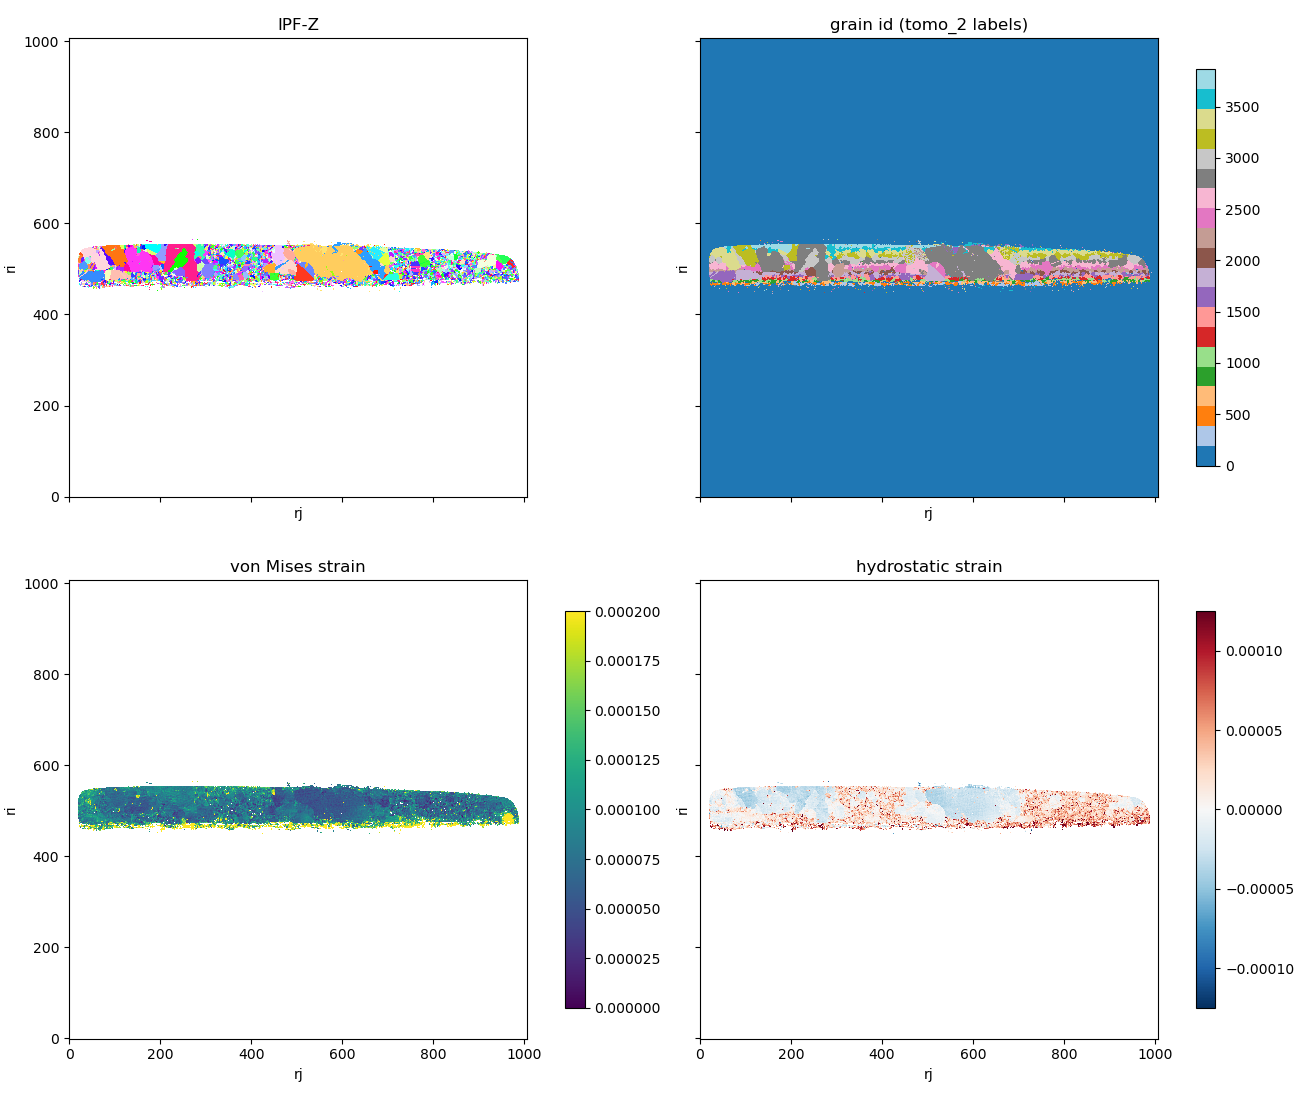

In [11]:
CHOSEN = {}

def _on_click(event):
    if event.inaxes not in tuple(axm) or event.xdata is None:
        return
    rj, ri = int(round(event.xdata)), int(round(event.ydata))
    if not (0 <= ri < NI and 0 <= rj < NJ) or not valid[ri, rj]:
        print('({},{}) not refined'.format(ri, rj))
        return
    idx = assign_peaks(ri, rj)
    CHOSEN.clear()
    CHOSEN.update(ri=ri, rj=rj, idx=idx, gid=GID[ri, rj])
    for mk in marks:
        mk.remove()
    marks.clear()
    for a in axm:
        marks.append(a.plot(rj, ri, 'k+', ms=14, mew=2)[0])
    figm.canvas.draw_idle()
    print('voxel ({},{})  gid {}  {} peaks  vM {:.3e}  hyd {:+.3e}'.format(
          ri, rj, CHOSEN['gid'], len(idx), VM[ri, rj], HY[ri, rj]))

figm, axm = plt.subplots(2, 2, figsize=(13, 11), constrained_layout=True,
                         sharex=True, sharey=True)
axm = axm.ravel()

axm[0].imshow(ipf, origin='lower', interpolation='nearest')
axm[0].set_title('IPF-Z')

im1 = axm[1].imshow(GID, origin='lower', interpolation='nearest', cmap='tab20')
axm[1].set_title(gid_name)
figm.colorbar(im1, ax=axm[1], shrink=.8)

im2 = axm[2].imshow(VM, origin='lower', interpolation='nearest',
                    vmin=0, vmax=2e-4)
axm[2].set_title('von Mises strain')
figm.colorbar(im2, ax=axm[2], shrink=.8)

hlim = np.nanpercentile(np.abs(HY), 99)
im3 = axm[3].imshow(HY, origin='lower', interpolation='nearest',
                    cmap='RdBu_r', vmin=-hlim, vmax=hlim)
axm[3].set_title('hydrostatic strain')
figm.colorbar(im3, ax=axm[3], shrink=.8)

for a in axm:
    a.set(xlabel='rj', ylabel='ri')
marks = []
MAP_FIG = figm
figm.canvas.mpl_connect('button_press_event', _on_click)
plt.show()

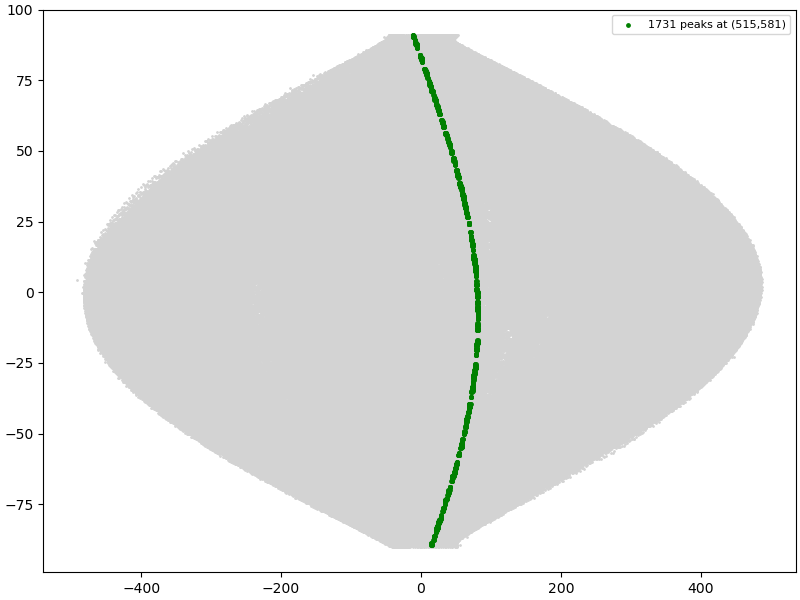

In [12]:
assert CHOSEN, 'click a voxel on the maps above first'
ri, rj, idx = CHOSEN['ri'], CHOSEN['rj'], CHOSEN['idx']
sx, sy = refine.sx_grid[ri, rj], refine.sy_grid[ri, rj]

figs, axs = plt.subplots(figsize=(8, 6), constrained_layout=True)
axs.scatter(dty_all[::37], icolf.omega[::37], s=1, color='lightgrey')
if len(idx):
    axs.scatter(dty_all[idx], icolf.omega[idx], s=6, color='green',
                label='{} peaks at ({},{})'.format(len(idx), ri, rj))


axs.legend(fontsize=8)

plt.show()



# 2. Strain per ring, for the chosen grain

Each peak gives a strain along its own scattering direction,
`eps = -(tth - tth_ring)/2 / tan(theta_ring)`, computed at the **corrected** distance
`distance - xpos_refined`. Averaged per ring.

A ring that sits well off zero while the others agree is either a real anisotropy or a
bad ring - the next cells tell you which.

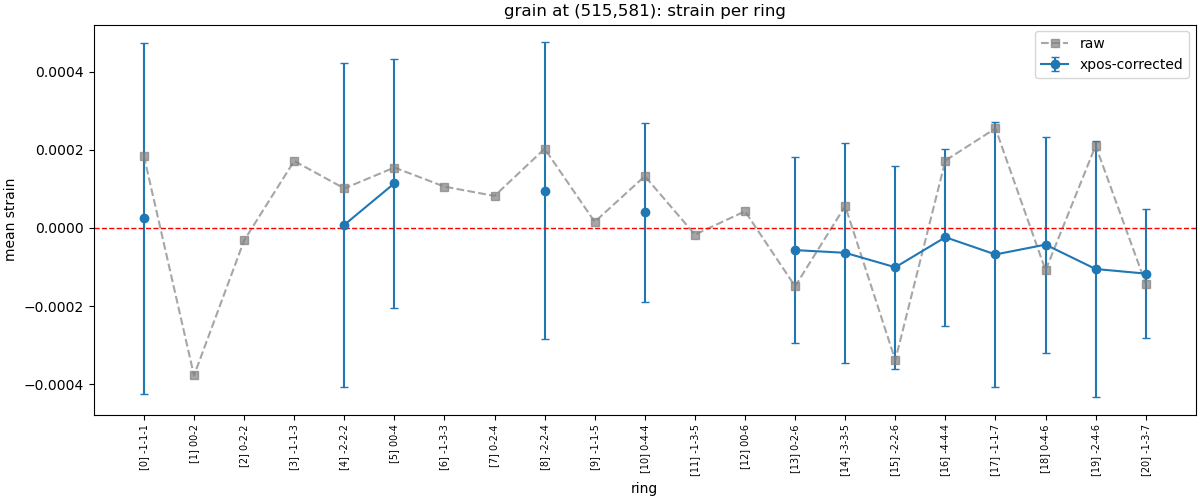

ring    hkl      n          raw    corrected         std
   0 -1-1-1    104    +1.84e-04    +2.48e-05    4.50e-04
   1   00-2     70    -3.78e-04         +nan         nan
   2  0-2-2    131    -3.20e-05         +nan         nan
   3 -1-1-3    202    +1.72e-04         +nan         nan
   4 -2-2-2     60    +1.01e-04    +7.98e-06    4.15e-04
   5   00-4     35    +1.55e-04    +1.14e-04    3.18e-04
   6 -1-3-3    133    +1.06e-04         +nan         nan
   7  0-2-4    110    +8.21e-05         +nan         nan
   8 -2-2-4    127    +2.03e-04    +9.52e-05    3.81e-04
   9 -1-1-5    228    +1.57e-05         +nan         nan
  10  0-4-4     65    +1.33e-04    +4.02e-05    2.29e-04
  11 -1-3-5    176    -1.70e-05         +nan         nan
  12   00-6    108    +4.28e-05         +nan         nan
  13  0-2-6     33    -1.49e-04    -5.67e-05    2.38e-04
  14 -3-3-5     50    +5.62e-05    -6.36e-05    2.81e-04
  15 -2-2-6     38    -3.39e-04    -1.01e-04    2.60e-04
  16 -4-4-4     14    +1.73e-04

In [13]:
assert CHOSEN, 'click a voxel on the maps above first'
idx = CHOSEN['idx']
tth_pk = np.asarray(icolf.tth, float)[idx]
xp = (np.asarray(icolf.xpos_refined, float)[idx]
      if 'xpos_refined' in icolf.titles else np.zeros(len(idx)))

def tth_at(sel, dist):
    """tth at a given sample-detector distance. transform.compute_tth_eta takes
    peaks as (sc, fc), omega as a keyword, and ignores extra kwds - so the whole
    parameter dict can be splatted with one key overridden."""
    t, _ = compute_tth_eta((np.asarray(icolf.sc, float)[sel],
                            np.asarray(icolf.fc, float)[sel]),
                           omega=np.asarray(icolf.omega, float)[sel],
                           **dict(pars, distance=dist))
    return t

rows = []
for i, t0 in enumerate(ring_tth):
    m = np.abs(tth_pk - t0) < ring_halfwidth_deg
    if m.sum() < 2:
        rows.append((i, int(m.sum()), np.nan, np.nan, np.nan))
        continue
    sel = idx[m]
    tc = tth_at(sel, pars['distance'] - xp[m])
    tr = tth_pk[m]
    th = np.radians(t0 / 2.0)
    e_c = -np.radians((tc - t0) / 2.0) / np.tan(th)
    e_r = -np.radians((tr - t0) / 2.0) / np.tan(th)
    rows.append((i, int(m.sum()), np.mean(e_r), np.mean(e_c), np.std(e_c)))

ri_, n_, er_, ec_, sc_ = (np.array(v, float) for v in zip(*rows))
ok = n_ >= 2

fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
ax.errorbar(ri_[ok], ec_[ok], yerr=sc_[ok], fmt='o-', capsize=3, label='xpos-corrected')
ax.plot(ri_[ok], er_[ok], 's--', color='grey', alpha=.7, label='raw')
ax.axhline(0, color='red', ls='--', lw=1)
ax.set_xticks(ri_[ok])
ax.set_xticklabels(['[{:.0f}] {}'.format(i, ring_lbl[int(i)]) for i in ri_[ok]],
                   rotation=90, fontsize=7)
ax.set(xlabel='ring', ylabel='mean strain',
       title='grain at ({},{}): strain per ring'.format(CHOSEN['ri'], CHOSEN['rj']))
ax.legend()
plt.show()

print('{:>4} {:>6} {:>6} {:>12} {:>12} {:>11}'.format(
      'ring', 'hkl', 'n', 'raw', 'corrected', 'std'))
for i, n, a, b, s in rows:
    if n >= 2:
        print('{:>4d} {:>6} {:>6d} {:+12.2e} {:+12.2e} {:11.2e}'.format(
              i, ring_lbl[i], n, a, b, s))

# 3. All peaks on the problematic ring

Set `RING` to the ring index you picked out above. 

In [14]:
from ImageD11.transform import compute_g_vectors, uncompute_g_vectors

idx = CHOSEN['idx']
ubi = best_ubi[CHOSEN['ri'], CHOSEN['rj']]
xp = np.asarray(icolf.xpos_refined, float)[idx]

def tth_eta_at(sel, dist):
    return compute_tth_eta((np.asarray(icolf.sc, float)[sel],
                            np.asarray(icolf.fc, float)[sel]),
                           omega=np.asarray(icolf.omega, float)[sel],
                           **dict(pars, distance=dist))

def wrap(d):
    return (np.asarray(d) + 180.0) % 360.0 - 180.0

USE_CORRECTED = True

om_o = np.asarray(icolf.omega, float)[idx]          # measured, never corrected
tth_o, eta_o = tth_eta_at(idx, pars['distance'] - xp if USE_CORRECTED
                          else pars['distance'])

wvln = float(pars['wavelength'])
wedge, chi = float(pars['wedge']), float(pars['chi'])
gobs = np.asarray(compute_g_vectors(tth_o, eta_o, om_o, wvln, wedge, chi))
hkl_obs = ubi.dot(gobs)
hkl_int = np.round(hkl_obs).astype(int)
gcalc = np.linalg.inv(ubi).dot(hkl_int)

tth_c, eta_cc, om_cc = uncompute_g_vectors(gcalc, wvln, wedge=wedge, chi=chi)
w = np.argmin([np.abs(wrap(eta_cc[0] - eta_o)),
               np.abs(wrap(eta_cc[1] - eta_o))], axis=0)
eta_calc = np.where(w == 0, eta_cc[0], eta_cc[1])
om_calc = np.where(w == 0, om_cc[0], om_cc[1])

omega_error = wrap(om_o - om_calc)
eta_error = wrap(eta_o - eta_calc)
tth_error = tth_o - tth_c
drlv = np.sqrt(((hkl_obs - hkl_int) ** 2).sum(axis=0))

print('grain at ({},{}): {} peaks, corrected={}'.format(
      CHOSEN['ri'], CHOSEN['rj'], len(idx), USE_CORRECTED))
for nm, e in (('omega', omega_error), ('eta', eta_error), ('tth', tth_error)):
    print('  {:>5} error: median {:+.4f}  RMS {:.4f}  |max| {:.3f} deg'.format(
          nm, np.median(e), np.sqrt(np.mean(e ** 2)), np.abs(e).max()))
print('  drlv: median {:.4f}  max {:.4f}'.format(np.median(drlv), drlv.max()))

grain at (515,581): 1731 peaks, corrected=True
  omega error: median -0.0002  RMS 9.0092  |max| 87.724 deg
    eta error: median +0.0005  RMS 13.4137  |max| 160.601 deg
    tth error: median +nan  RMS nan  |max| nan deg
  drlv: median nan  max nan


/tmp/ipykernel_2155911/1219540133.py:26: RuntimeWarning: invalid value encountered in cast
  hkl_int = np.round(hkl_obs).astype(int)
/home/esrf/aditya7c/Code/ImageD11/ImageD11/transform.py:559: RuntimeWarning: invalid value encountered in arcsin
  tth = np.degrees(np.arcsin(s) * 2.0) * valid


ring 5 (00-4), tth_ring 18.5752, 35 of 1731 grain peaks
omega error: median +0.0047  RMS 0.0513  |max| 0.136
tth error  : median -0.0002  RMS 0.0065  |max| 0.014


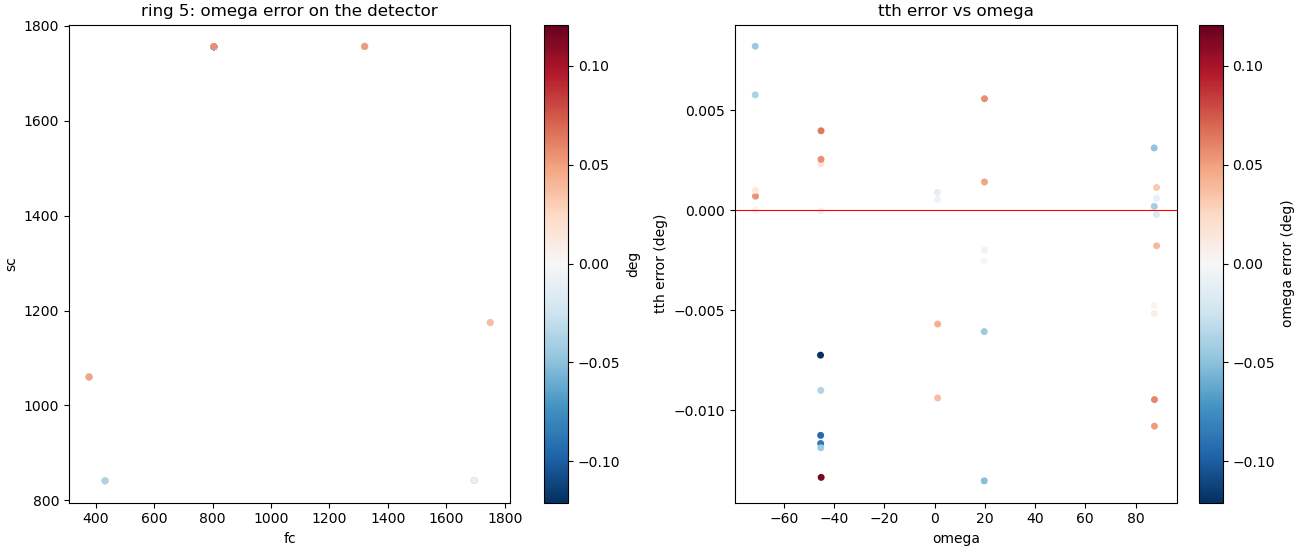


worst 10 by |tth error|
   k    icolf row    omega      dty       tth     xpos     om_err    tth_err     drlv         I
1241      9923503    19.72    72.00   18.5625    38.90    -0.0515    -0.0135   0.0046       132
1063      9757928   -45.22    65.00   18.5624   -50.30    +0.1137    -0.0134   0.0045        12
1100      9771899   -45.38    66.00   18.5639   -55.99    -0.0436    -0.0119   0.0027      7057
1079      9757964   -45.42    65.00   18.5641   -52.22    -0.0863    -0.0117   0.0031        76
1096      9771889   -45.43    66.00   18.5645   -55.14    -0.0936    -0.0113   0.0032        42
  39      7800796    87.52    -6.00   18.5649    85.33    +0.0517    -0.0108   0.0025       768
  32      7741594    87.52    -7.00   18.5663    84.19    +0.0589    -0.0095   0.0024       347
1613     10113362     1.17    80.00   18.5666    12.63    +0.0371    -0.0094   0.0031       330
1075      9757957   -45.37    65.00   18.5667   -50.98    -0.0363    -0.0090   0.0021     12961
 542      90205

In [15]:

RING = 5          # <-- edit me

t0 = ring_tth[RING]
rm = np.abs(tth_o - t0) < ring_halfwidth_deg
rk = np.nonzero(rm)[0]                 # positions within the grain's peak list

fx = np.asarray(icolf.fc, float)[idx][rm]
fy = np.asarray(icolf.sc, float)[idx][rm]
oe, te = omega_error[rm], tth_error[rm]
omr, dtyr = om_o[rm], dty_all[idx][rm]

print('ring {} ({}), tth_ring {:.4f}, {} of {} grain peaks'.format(
      RING, ring_lbl[RING], t0, len(rk), len(idx)))
print('omega error: median {:+.4f}  RMS {:.4f}  |max| {:.3f}'.format(
      np.median(oe), np.sqrt(np.mean(oe ** 2)), np.abs(oe).max()))
print('tth error  : median {:+.4f}  RMS {:.4f}  |max| {:.3f}'.format(
      np.median(te), np.sqrt(np.mean(te ** 2)), np.abs(te).max()))

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)
v = np.nanpercentile(np.abs(oe), 98)

im = ax[0].scatter(fx, fy, c=oe, s=16, cmap='RdBu_r', vmin=-v, vmax=v)
ax[0].set(xlabel='fc', ylabel='sc',
          title='ring {}: omega error on the detector'.format(RING))
fig.colorbar(im, ax=ax[0], label='deg')

s1 = ax[1].scatter(omr, te, s=16, c=oe, cmap='RdBu_r', vmin=-v, vmax=v)
ax[1].axhline(0, color='r', lw=0.8)
ax[1].set(xlabel='omega', ylabel='tth error (deg)', title='tth error vs omega')
fig.colorbar(s1, ax=ax[1], label='omega error (deg)')

RING_FIG = fig
plt.show()

# ---- table, so a peak can be chosen by hand ----------------------------
hdr = ('{:>4} {:>12} {:>8} {:>8} {:>9} {:>8} {:>10} {:>10} {:>8} {:>9}'.format(
       'k', 'icolf row', 'omega', 'dty', 'tth', 'xpos',
       'om_err', 'tth_err', 'drlv', 'I'))

def row(j):
    k = int(rk[j])
    r = int(idx[k])
    return ('{:>4d} {:>12d} {:>8.2f} {:>8.2f} {:>9.4f} {:>8.2f} '
            '{:>+10.4f} {:>+10.4f} {:>8.4f} {:>9.0f}'.format(
            k, r, om_o[k], dty_all[r], tth_o[k], xp[k],
            omega_error[k], tth_error[k], drlv[k], icolf.sum_intensity[r]))

print('\nworst 10 by |tth error|')
print(hdr)
for j in np.argsort(-np.abs(te))[:10]:
    print(row(j))

print('\nall {} peaks on this ring'.format(len(rk)))
print(hdr)
for j in range(len(rk)):
    print(row(j))

# 4. One peak: where did its origin come from?

 This redoes `compute_origins` for that peak in
plain numpy: every voxel on its ray, which ones its g-vector indexes, and the weighted
mean that became `xpos_refined`.

peak 9905106: omega -45.47  dty 71.00
250 voxels on the ray, 191 accepted
recomputed lx = -63.3978   stored xpos_refined = -63.3978
accepted voxels form 3 connected lump(s)


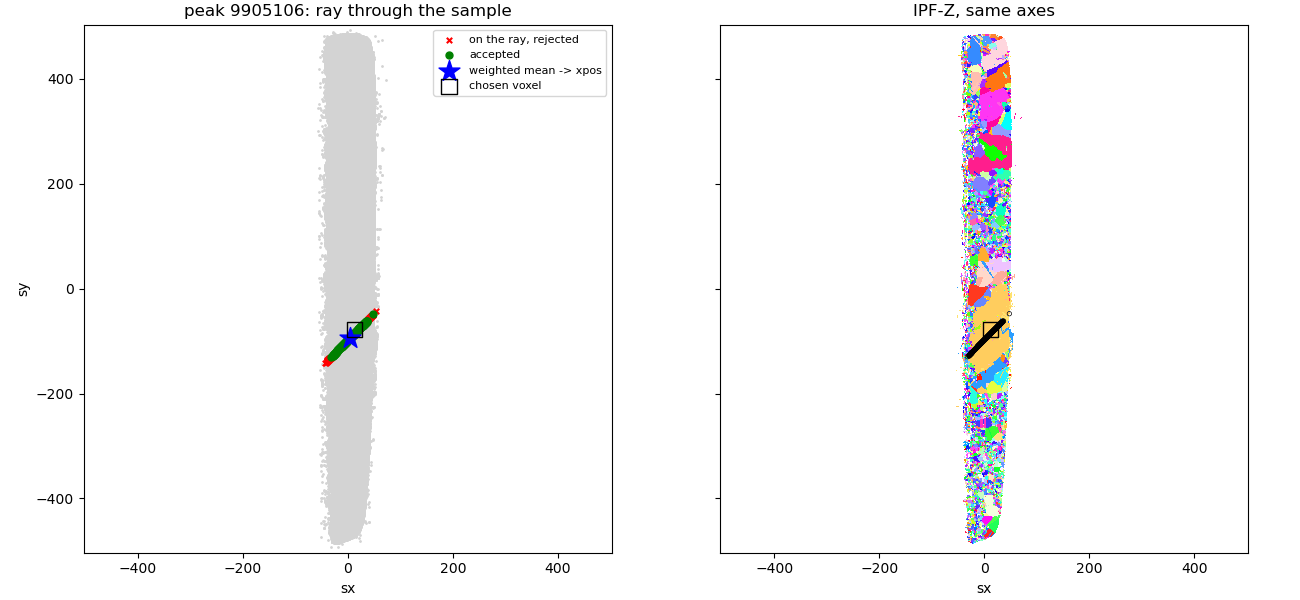

In [16]:
PEAK_IDX=9905106   

def peak_origin_candidates(peak_idx, hkl_tol=None):
    if hkl_tol is None:
        hkl_tol = refine.hkl_tol_origins
    weight_reg = getattr(refine, 'beam_size', refine.ystep) / 3.0
    so, co = sinom[peak_idx], cosom[peak_idx]
    g = gve_all[peak_idx]
    ygrid = refine.y0 - refine.sx_grid * so - refine.sy_grid * co
    ydist_grid = np.abs(dty_all[peak_idx] - ygrid)
    ii, jj = np.nonzero((ydist_grid <= refine.ystep) & refine.mask)
    ydist = ydist_grid[ii, jj]
    acc = np.zeros(len(ii), bool)
    err = np.full(len(ii), np.nan)
    for k in range(len(ii)):
        o = refine.singlemap[ii[k], jj[k]]
        if np.isnan(o[0, 0]):
            continue
        hf = o.dot(g)
        err[k] = ((hf - np.round(hf)) ** 2).sum()
        acc[k] = err[k] < hkl_tol * hkl_tol
    r = dict(ii=ii, jj=jj, ydist=ydist, err=err, accepted=acc,
             sx=refine.sx_grid[ii, jj], sy=refine.sy_grid[ii, jj],
             n_ray=len(ii), n_accepted=int(acc.sum()))
    if acc.any():
        w = weight_reg / (ydist[acc] + weight_reg)
        r['sx_avg'] = np.average(r['sx'][acc], weights=w)
        r['sy_avg'] = np.average(r['sy'][acc], weights=w)
        r['lx'] = r['sx_avg'] * co - r['sy_avg'] * so
    else:
        r['sx_avg'] = r['sy_avg'] = r['lx'] = np.nan
    return r

res = peak_origin_candidates(PEAK_IDX)
print('peak {}: omega {:.2f}  dty {:.2f}'.format(
      PEAK_IDX, icolf.omega[PEAK_IDX], dty_all[PEAK_IDX]))
print('{} voxels on the ray, {} accepted'.format(res['n_ray'], res['n_accepted']))
print('recomputed lx = {:.4f}   stored xpos_refined = {:.4f}'.format(
      res['lx'], icolf.xpos_refined[PEAK_IDX]))

img = np.zeros(refine.mask.shape, bool)
img[res['ii'][res['accepted']], res['jj'][res['accepted']]] = True
lab, nlab = ndimage.label(img, structure=np.ones((3, 3), bool))
print('accepted voxels form {} connected lump(s)'.format(nlab))

# map order: (Z, Y, X) -> rows = Y = sy, cols = X = sx. No transpose needed.
if 'ipf_map' not in globals():
    ipf_map = tmap['ipf_z'][0].copy()
    ipf_map[tmap['phase_ids'][0] < 0] = [1, 1, 1]

ext = [refine.sx_grid.min(), refine.sx_grid.max(),
       refine.sy_grid.min(), refine.sy_grid.max()]
rej = ~res['accepted']
vx = refine.sx_grid[CHOSEN['ri'], CHOSEN['rj']]
vy = refine.sy_grid[CHOSEN['ri'], CHOSEN['rj']]

fig, ax = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True,
                       sharex=True, sharey=True)

ax[0].scatter(refine.sx_grid[refine.mask], refine.sy_grid[refine.mask],
              s=1, color='lightgrey')
ax[0].scatter(res['sx'][rej], res['sy'][rej], s=15, color='red', marker='x',
              label='on the ray, rejected')
ax[0].scatter(res['sx'][res['accepted']], res['sy'][res['accepted']], s=25,
              color='green', label='accepted')
if np.isfinite(res['sx_avg']):
    ax[0].scatter([res['sx_avg']], [res['sy_avg']], s=250, marker='*',
                  color='blue', label='weighted mean -> xpos')
ax[0].scatter([vx], [vy], s=120, marker='s', facecolor='none', edgecolor='k',
              label='chosen voxel')
ax[0].set(xlabel='sx', ylabel='sy', aspect='equal',
          title='peak {}: ray through the sample'.format(PEAK_IDX))
ax[0].legend(fontsize=8)

ax[1].imshow(ipf_map, extent=ext, origin='lower', aspect='equal',
             interpolation='nearest')
ax[1].scatter(res['sx'][res['accepted']], res['sy'][res['accepted']], s=10,
              facecolor='none', edgecolor='k', lw=.5)
ax[1].scatter([vx], [vy], s=120, marker='s', facecolor='none', edgecolor='k')
ax[1].set(xlabel='sx', title='IPF-Z, same axes')
plt.show()

# 5. The peak on the detector

Loads the sparse frame this peak came from and shows the blob, its centre of mass from
the pixels, and the centroid stored in the columnfile.

`icolf` peaks are **merged over frames**, so the stored `sc/fc` is the centroid of the
whole 3D spot while the COM here is one frame of it. They should be close but need not
be identical - a large gap means the merge pulled the centroid, which is exactly the
kind of thing that shifts tth and therefore strain.

In [17]:
from ImageD11.sparseframe import SparseScan

HALF = 30                 # zoom half-width in pixels

om_pk = float(icolf.omega[PEAK_IDX])
dty_pk = float(dty_all[PEAK_IDX])
sc_pk = float(icolf.sc[PEAK_IDX])
fc_pk = float(icolf.fc[PEAK_IDX])
print('peak {}: omega {:.3f}  dty {:.3f}  row(sc) {:.1f}  col(fc) {:.1f}'.format(
      PEAK_IDX, om_pk, dty_pk, sc_pk, fc_pk))

# --- which (scan, frame)? mismatch measured in STEPS, not raw units ---
om_grid, dty_grid = np.asarray(ds.omega), np.asarray(ds.dty)
om_step = np.median(np.abs(np.diff(om_grid[0])))
dom = (om_grid - om_pk + 180.0) % 360.0 - 180.0
cost = (dom / om_step) ** 2 + ((dty_grid - dty_pk) / ds.ystep) ** 2
scan_i, frame_i = np.unravel_index(np.argmin(cost), cost.shape)
scan_i, frame_i = int(scan_i), int(frame_i)

print("scan {} ('{}')  frame {}".format(scan_i, ds.scans[scan_i], frame_i))
print('  omega off by {:.2f} steps, dty off by {:.2f} steps   (>0.5 is suspect)'
      .format(abs(dom[scan_i, frame_i]) / om_step,
              abs(dty_grid[scan_i, frame_i] - dty_pk) / ds.ystep))

# --- load that frame and build the dense image from its pixels ---
sfile = getattr(ds, 'sparsefile', None)
if sfile is None:                                  # some datasets have a list
    sfile = ds.sparsefiles[scan_i]
frame = SparseScan(sfile, ds.scans[scan_i]).getframe(frame_i)
if frame is None:
    raise RuntimeError('frame {} of {} has no segmented pixels'.format(
        frame_i, ds.scans[scan_i]))

dense = np.zeros(frame.shape, np.float32)
dense[frame.row, frame.col] = (frame.pixels['intensity']
                               if 'intensity' in frame.pixels
                               else np.ones(len(frame.row)))
print('frame {}, {} nonzero pixels'.format(dense.shape, int((dense > 0).sum())))

peak 9905106: omega -45.469  dty 71.000  row(sc) 1756.7  col(fc) 804.1
scan 571 ('572.1')  frame 2729
  omega off by 0.00 steps, dty off by 0.00 steps   (>0.5 is suspect)
frame (2162, 2068), 13 nonzero pixels


blob: 2 px, sumI 9, max 5, COM row 1756.44 col 804.00
COM - icolf centroid: ds -0.26  df -0.08 px
spatial correction: ds +0.26  df +0.08 px


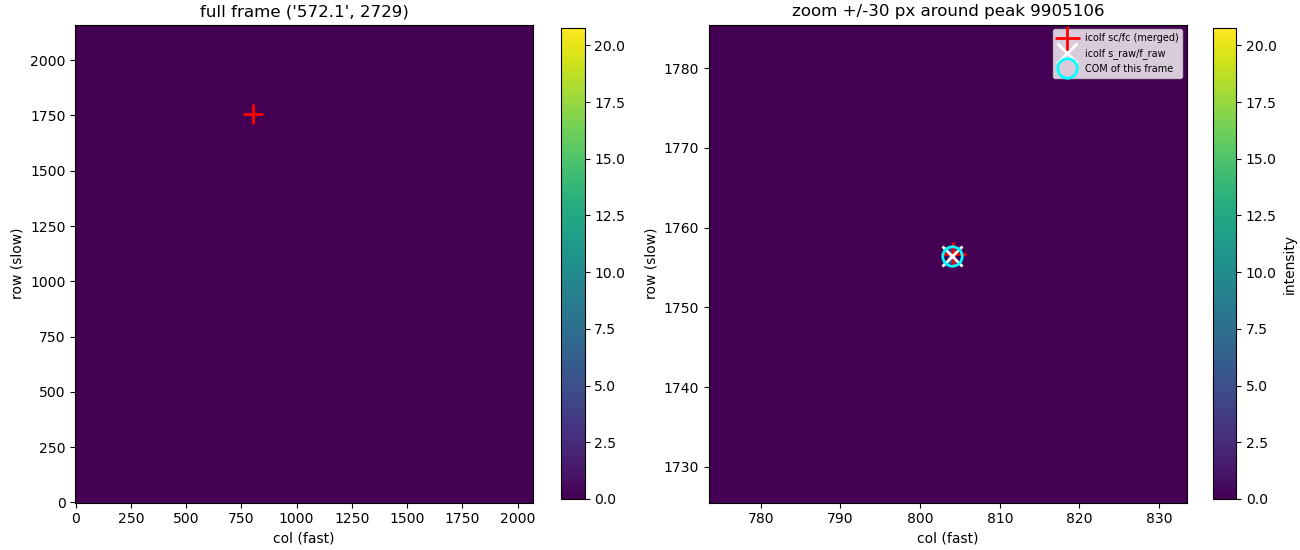

In [18]:
r0, r1 = int(max(sc_pk - HALF, 0)), int(min(sc_pk + HALF, dense.shape[0]))
c0, c1 = int(max(fc_pk - HALF, 0)), int(min(fc_pk + HALF, dense.shape[1]))
crop = dense[r0:r1, c0:c1]

lab_d, nlab_d = ndimage.label(crop > 0)
com_s = com_f = np.nan
if nlab_d:
    cens = np.array(ndimage.center_of_mass(crop, lab_d, range(1, nlab_d + 1)))
    which = np.argmin((cens[:, 0] + r0 - sc_pk) ** 2 + (cens[:, 1] + c0 - fc_pk) ** 2)
    mblob = lab_d == (which + 1)
    rr, cc = np.nonzero(mblob)
    w = crop[rr, cc]
    com_s = (rr * w).sum() / w.sum() + r0
    com_f = (cc * w).sum() / w.sum() + c0
    print('blob: {} px, sumI {:.0f}, max {:.0f}, COM row {:.2f} col {:.2f}'.format(
          int(mblob.sum()), w.sum(), w.max(), com_s, com_f))
    print('COM - icolf centroid: ds {:+.2f}  df {:+.2f} px'.format(
          com_s - sc_pk, com_f - fc_pk))

has_raw = ('s_raw' in icolf.titles) and ('f_raw' in icolf.titles)
if has_raw:
    print('spatial correction: ds {:+.2f}  df {:+.2f} px'.format(
          sc_pk - icolf.s_raw[PEAK_IDX], fc_pk - icolf.f_raw[PEAK_IDX]))

# one scale for both panels, so the blob is comparable with the rest of the frame
nz = dense[dense > 0]
vmax = np.percentile(nz, 99.5) if nz.size else 1

fig, axs = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)
im0 = axs[0].imshow(dense, origin='lower', cmap='viridis', vmax=vmax)
axs[0].plot(fc_pk, sc_pk, 'r+', ms=14, mew=2)
axs[0].set(title="full frame ('{}', {})".format(ds.scans[scan_i], frame_i),
           xlabel='col (fast)', ylabel='row (slow)')
fig.colorbar(im0, ax=axs[0], fraction=.046)

# pixel CENTRES at integer coordinates, matching the default imshow convention
im1 = axs[1].imshow(crop, origin='lower', cmap='viridis', vmax=vmax,
                    extent=[c0 - 0.5, c1 - 0.5, r0 - 0.5, r1 - 0.5])
axs[1].plot(fc_pk, sc_pk, 'r+', ms=18, mew=2, label='icolf sc/fc (merged)')
if has_raw:
    axs[1].plot(icolf.f_raw[PEAK_IDX], icolf.s_raw[PEAK_IDX], 'wx', ms=14, mew=2,
                label='icolf s_raw/f_raw')
if np.isfinite(com_s):
    axs[1].plot(com_f, com_s, 'o', mfc='none', mec='cyan', ms=14, mew=2,
                label='COM of this frame')
axs[1].set(title='zoom +/-{} px around peak {}'.format(HALF, PEAK_IDX),
           xlabel='col (fast)', ylabel='row (slow)')
axs[1].legend(fontsize=7, loc='upper right')
fig.colorbar(im1, ax=axs[1], fraction=.046, label='intensity')
plt.show()

## What to look for

**Step 2** - Look for a ring that does not represent expected strain levels in the sample

**Step 3** - Which peak or peaks seems to prodce an outlier peak?

**Step 4** -Does peak origin work as expected.

**Step 5** - Is the raw detected peak, saturated or near a mask?